In [3]:
import pandas as pd
import re

# ====== 0) 입력 파일 경로 ======
in_path = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/251207_segmentation_area_mm2.csv"  # 너 파일 경로로 바꿔도 됨
out_path = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/4. 결과 출력 시각화/251207_bed_date_cam0_area_stats.csv"

# ====== 1) 로드 ======
df = pd.read_csv(in_path)

# ====== 2) lettuce_name에서 bed/date/time/cam/slot 파싱 ======
# 예: bed03_20251207_153012_cam0_00.png
pat = re.compile(
    r"^bed(?P<bed>\d{2})_(?P<date>\d{8})_(?P<time>\d{6})_(?P<cam>cam\d)_(?P<slot>\d{2})\.(png|jpg|jpeg)$",
    re.IGNORECASE
)

parsed = df["lettuce_name"].astype(str).str.extract(pat)
df = pd.concat([df, parsed], axis=1)

# (선택) 파싱 실패한 행 확인
bad = df[df["bed"].isna() | df["date"].isna() | df["cam"].isna()]
if len(bad) > 0:
    print(f"[경고] 파일명 파싱 실패 행: {len(bad)}개 (패턴 불일치 가능)")
    # print(bad[["lettuce_name"]].head(20))

# ====== 3) cam0만 남기기 (시간은 이후 그룹에서 자동 무시됨) ======
df_cam0 = df[df["cam"].str.lower() == "cam0"].copy()

# ====== 4) bed-date로 그룹 묶어서 기본통계 ======
def q25(x): return x.quantile(0.25)
def q75(x): return x.quantile(0.75)

# area_mm2 컬럼명이 다르면 여기만 바꿔
area_col = "area_mm2"

agg = (
    df_cam0
    .groupby(["bed", "date"], dropna=False)
    .agg(
        n=(area_col, "count"),
        mean_mm2=(area_col, "mean"),
        std_mm2=(area_col, "std"),
        min_mm2=(area_col, "min"),
        q25_mm2=(area_col, q25),
        median_mm2=(area_col, "median"),
        q75_mm2=(area_col, q75),
        max_mm2=(area_col, "max"),
    )
    .reset_index()
)

# bed를 숫자로 정렬되게
agg["bed"] = agg["bed"].astype(int)
agg = agg.sort_values(["bed", "date"]).reset_index(drop=True)

# ====== 5) 저장 ======
agg.to_csv(out_path, index=False, encoding="utf-8-sig")

print("완료!")
print("입력:", in_path)
print("출력:", out_path)
agg.head(20)


완료!
입력: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/251207_segmentation_area_mm2.csv
출력: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/4. 결과 출력 시각화/251207_bed_date_cam0_area_stats.csv


,bed,date,n,mean_mm2,std_mm2,min_mm2,q25_mm2,median_mm2,q75_mm2,max_mm2
0,0,20251204,48,35588.257173,13894.737141,17218.820900,26139.358005,31277.998375,39811.404790,67000.206040
1,0,20251205,72,35766.596825,13987.874332,9007.722781,27234.583787,39230.057255,47133.368910,55371.301120
2,1,20251130,24,21233.692028,3252.937627,18313.006770,18898.030227,19979.437210,22702.159975,28831.610210
3,1,20251202,24,58351.615092,8325.023379,42000.255830,51693.933048,60606.923850,64128.410710,72356.058800
4,1,20251203,12,60089.626188,7269.142628,46230.644670,53699.906288,62708.244275,66100.047650,67923.597850
5,1,20251204,108,30963.153522,10437.027625,16974.668420,25108.079440,27395.596040,33604.532802,61980.814500
6,1,20251205,96,45425.150080,14807.204919,27213.032150,35700.049347,41918.795480,48074.564120,89088.928240
7,1,20251206,144,36657.091208,15675.213806,7558.767137,23851.323532,38326.086205,49600.384455,63933.701620
8,2,20251201,12,57734.500378,7986.544132,46546.130660,51228.285807,58367.485235,64133.204155,67884.001820
9,2,20251202,48,59126.858897,6126.671786,44765.850990,55449.111908,60986.643140,64171.907782,67070.606540


### Manus 말대로 시각화 하기


1.   기본 설정 및 데이터 로딩
2.   정규분포 분석: 기본통계분석
3.   베드별 분석
4.   상추별 분석
5.   이상치 탐지
6.   모델 정제도 평가
7.   통합 분석 실행 스크립트
8. 고급 분석 기법
9. 결과 저장 및 내보내기

### 1. 기본 설정 및 데이터 로딩




In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest, anderson, kstest
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로딩
df = pd.read_csv('/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_윗면/251207_segmentation_area_mm2.csv', encoding='utf-8-sig')
area_data = df['area_cm2'].dropna()

print(f"총 레코드: {len(df)}")
print(f"고유 베드: {df['parent_name'].nunique()}")
print(f"고유 상추: {df['lettuce_name'].nunique()}")

총 레코드: 18840
고유 베드: 1564
고유 상추: 18768


###2. 정규분포 분석


2.1.   기본 통계 및 정규성 검정\
2.2.   정규분포 시각화\




In [6]:
# 2.1 기본통계 및 정규성 검정

def analyze_normality(data):
    """정규분포 검정 및 통계 분석"""

    print("=" * 60)
    print("정규분포 분석")
    print("=" * 60)

    # 기본 통계
    print(f"\n기본 통계:")
    print(f"  평균: {data.mean():.2f}")
    print(f"  중앙값: {data.median():.2f}")
    print(f"  표준편차: {data.std():.2f}")
    print(f"  왜도: {stats.skew(data):.4f}")
    print(f"  첨도: {stats.kurtosis(data):.4f}")

    # 정규성 검정
    print(f"\n정규성 검정:")

    # Shapiro-Wilk
    if len(data) <= 5000:
        stat_shapiro, p_shapiro = shapiro(data)
    else:
        sample_data = np.random.choice(data, 5000, replace=False)
        stat_shapiro, p_shapiro = shapiro(sample_data)
    print(f"  Shapiro-Wilk: p-value = {p_shapiro:.6e}")

    # D'Agostino-Pearson
    stat_dagostino, p_dagostino = normaltest(data)
    print(f"  D'Agostino-Pearson: p-value = {p_dagostino:.6e}")

    # Kolmogorov-Smirnov
    stat_ks, p_ks = kstest(data, 'norm', args=(data.mean(), data.std()))
    print(f"  Kolmogorov-Smirnov: p-value = {p_ks:.6e}")

    return {
        'mean': data.mean(),
        'std': data.std(),
        'skew': stats.skew(data),
        'kurtosis': stats.kurtosis(data),
        'p_shapiro': p_shapiro,
        'p_dagostino': p_dagostino,
        'p_ks': p_ks
    }

# 실행
normality_results = analyze_normality(area_data)

정규분포 분석

기본 통계:
  평균: 399.01
  중앙값: 364.50
  표준편차: 212.88
  왜도: 0.4415
  첨도: -0.2266

정규성 검정:
  Shapiro-Wilk: p-value = 4.143841e-31
  D'Agostino-Pearson: p-value = 1.351827e-133
  Kolmogorov-Smirnov: p-value = 8.907972e-120


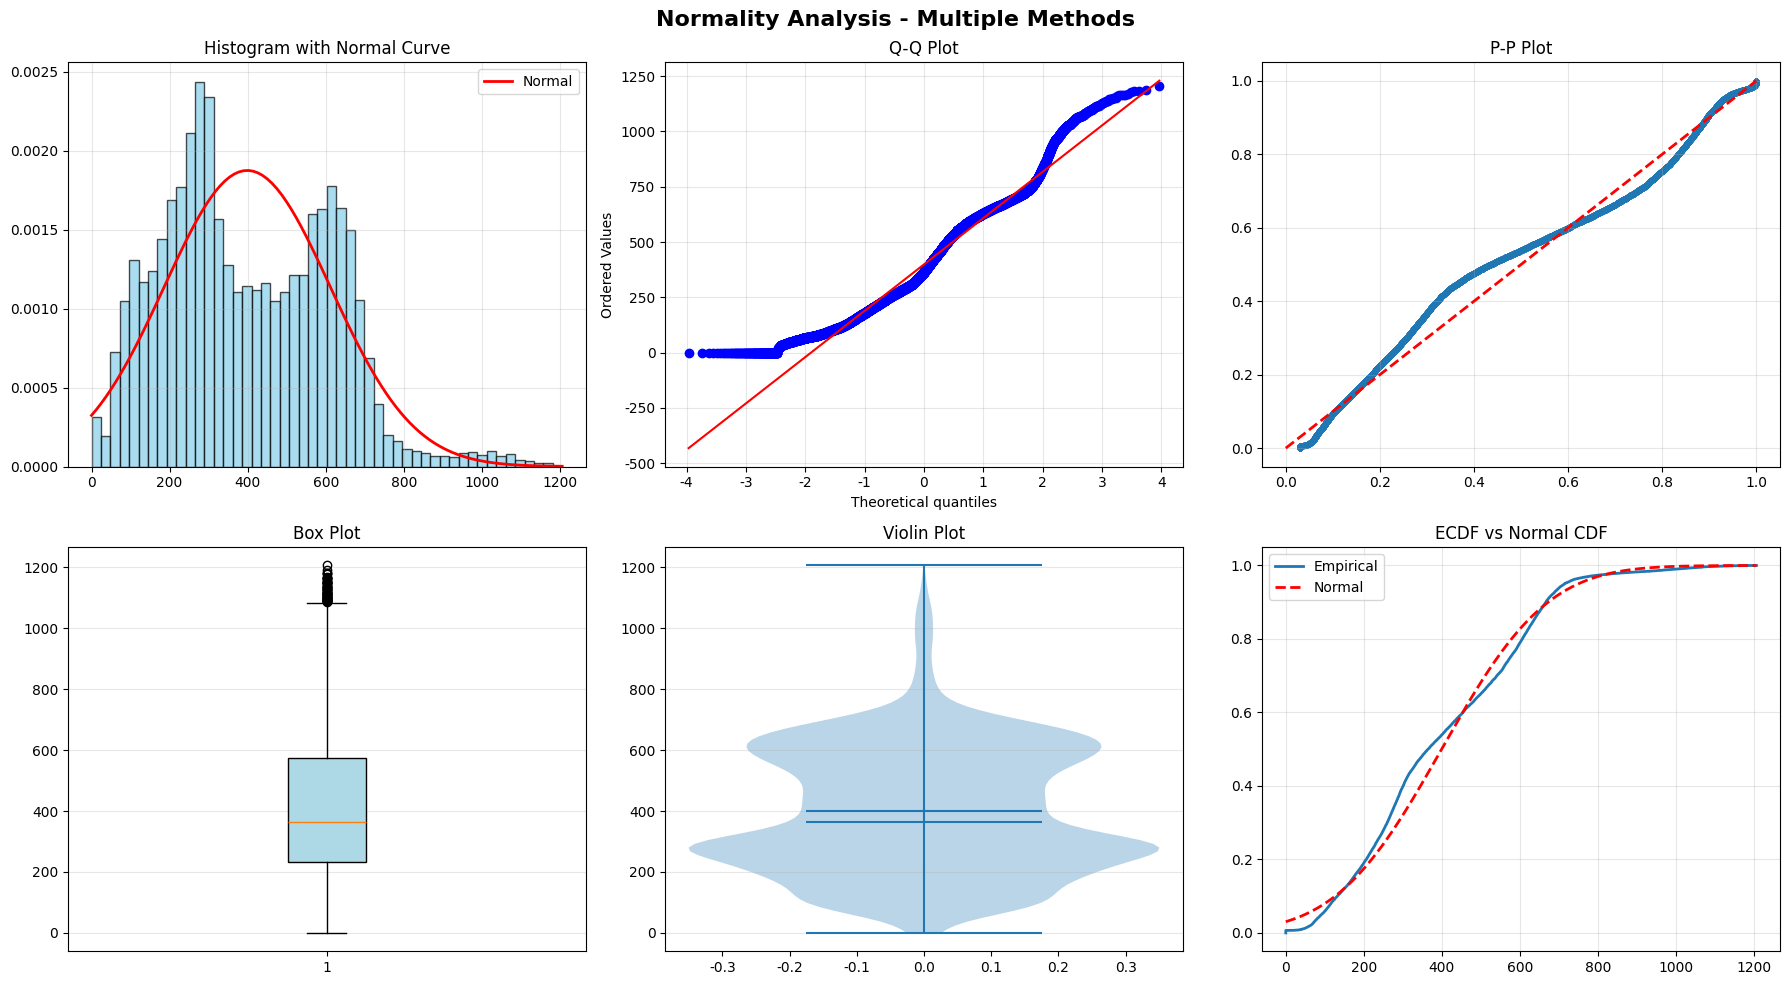

In [7]:
# 2. 정규분포 시각화
def plot_normality_analysis(data):
    """정규분포 분석 시각화"""

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Normality Analysis - Multiple Methods', fontsize=16, fontweight='bold')

    mu, sigma = data.mean(), data.std()

    # 1. 히스토그램 + 정규분포 곡선
    ax = axes[0, 0]
    n, bins, patches = ax.hist(data, bins=50, density=True, alpha=0.7,
                               color='skyblue', edgecolor='black')
    x = np.linspace(data.min(), data.max(), 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal')
    ax.set_title('Histogram with Normal Curve')
    ax.legend()
    ax.grid(alpha=0.3)

    # 2. Q-Q Plot
    ax = axes[0, 1]
    stats.probplot(data, dist="norm", plot=ax)
    ax.set_title('Q-Q Plot')
    ax.grid(alpha=0.3)

    # 3. P-P Plot
    ax = axes[0, 2]
    sorted_data = np.sort(data)
    p = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    theoretical_p = stats.norm.cdf(sorted_data, mu, sigma)
    ax.scatter(theoretical_p, p, alpha=0.5, s=10)
    ax.plot([0, 1], [0, 1], 'r--', linewidth=2)
    ax.set_title('P-P Plot')
    ax.grid(alpha=0.3)

    # 4. Box Plot
    ax = axes[1, 0]
    bp = ax.boxplot(data, vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    ax.set_title('Box Plot')
    ax.grid(alpha=0.3, axis='y')

    # 5. Violin Plot
    ax = axes[1, 1]
    parts = ax.violinplot([data], positions=[0], widths=0.7,
                         showmeans=True, showmedians=True)
    ax.set_title('Violin Plot')
    ax.grid(alpha=0.3, axis='y')

    # 6. ECDF
    ax = axes[1, 2]
    sorted_data = np.sort(data)
    ecdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(sorted_data, ecdf, linewidth=2, label='Empirical')
    theoretical_cdf = stats.norm.cdf(sorted_data, mu, sigma)
    ax.plot(sorted_data, theoretical_cdf, 'r--', linewidth=2, label='Normal')
    ax.set_title('ECDF vs Normal CDF')
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('normality_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# 실행
plot_normality_analysis(area_data)

###3. 베드별 분석


1.   베드별 통계
2.   베드별 시각화




In [22]:
def analyze_beds(df):
    """베드별 분석"""

    bed_stats = df.groupby('parent_name')['area_cm2'].agg([
        'count', 'mean', 'median', 'std', 'min', 'max',
        ('range', lambda x: x.max() - x.min()),
        ('cv', lambda x: x.std() / x.mean() * 100)
    ]).round(2)

    bed_stats = bed_stats.sort_values('mean', ascending=False)

    print("=" * 60)
    print("베드별 분석")
    print("=" * 60)
    print(f"\n상위 10개 베드:")
    print(bed_stats.head(10))
    print(f"\n하위 10개 베드:")
    print(bed_stats.tail(10))

    # 베드 성장 품질 분류
    excellent = bed_stats[(bed_stats['cv'] < 10) &
                         (bed_stats['mean'] > bed_stats['mean'].quantile(0.5))]
    good = bed_stats[(bed_stats['cv'] < 15) &
                    (bed_stats['mean'] > bed_stats['mean'].quantile(0.25))]
    fair = bed_stats[(bed_stats['cv'] < 25) |
                    (bed_stats['mean'] > bed_stats['mean'].quantile(0.1))]
    poor = bed_stats[~bed_stats.index.isin(fair.index)]

    print(f"\n성장 품질 분류:")
    print(f"  Excellent: {len(excellent)} ({len(excellent)/len(bed_stats)*100:.1f}%)")
    print(f"  Good: {len(good)} ({len(good)/len(bed_stats)*100:.1f}%)")
    print(f"  Fair: {len(fair)} ({len(fair)/len(bed_stats)*100:.1f}%)")
    print(f"  Poor: {len(poor)} ({len(poor)/len(bed_stats)*100:.1f}%)")

    return bed_stats

bed_stats = analyze_beds(df)

베드별 분석

상위 10개 베드:
                            count     mean   median    std     min     max  \
parent_name                                                                  
bed02_20251205_194805_cam1     12  1101.00  1107.85  66.94   942.1  1189.7   
bed28_20251206_125119_cam1     12  1095.23  1093.25  57.16  1029.2  1205.8   
bed28_20251206_155447_cam1     12  1076.26  1078.60  55.96   989.9  1164.7   
bed28_20251206_185851_cam1     12  1074.12  1061.30  54.96  1014.7  1178.3   
bed25_20251204_110403_cam1     12  1063.73  1069.45  69.63   965.5  1168.5   
bed25_20251205_132655_cam1     12  1058.40  1060.35  77.88   867.5  1145.5   
bed25_20251204_140756_cam1     12  1057.23  1070.10  78.52   929.0  1166.1   
bed25_20251204_075948_cam1     12  1047.41  1046.65  70.13   936.7  1152.8   
bed25_20251204_171141_cam1     12  1045.41  1046.95  64.70   948.4  1135.6   
bed02_20251206_065200_cam1     12  1040.36  1033.55  64.28   894.3  1148.5   

                            range    cv  
pa

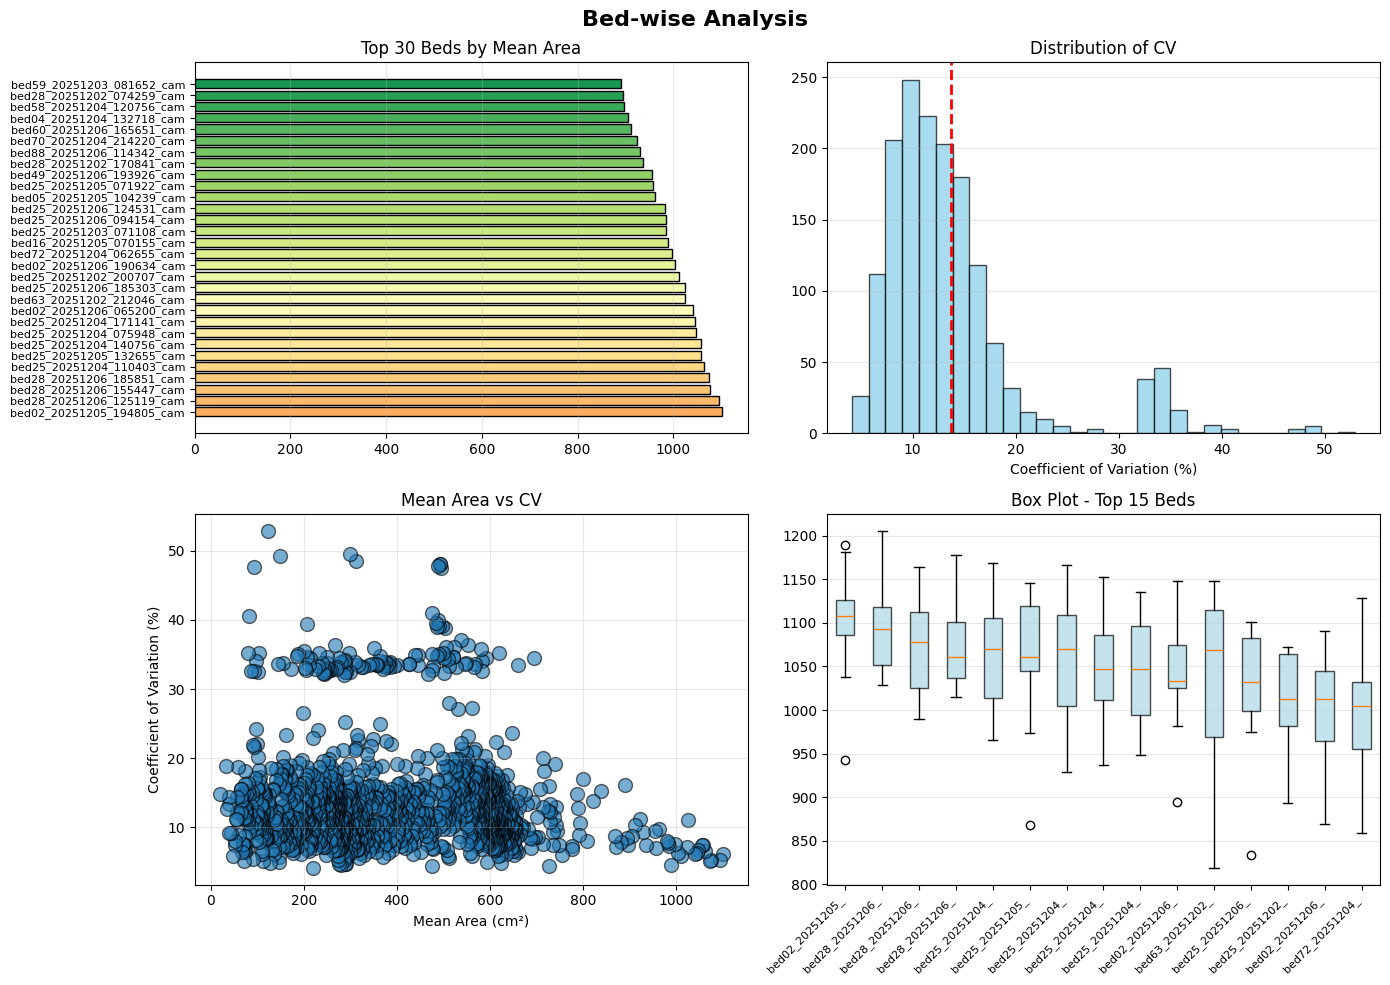

In [21]:
#3.2 베드별 시각화
def plot_bed_analysis(df, bed_stats):
    """베드별 분석 시각화"""

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Bed-wise Analysis', fontsize=16, fontweight='bold')

    # 1. 평균 면적 분포
    ax = axes[0, 0]
    top_30 = bed_stats.head(30)
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_30)))
    ax.barh(range(len(top_30)), top_30['mean'], color=colors, edgecolor='black')
    ax.set_yticks(range(len(top_30)))
    ax.set_yticklabels([name[:25] for name in top_30.index], fontsize=8)
    ax.set_title('Top 30 Beds by Mean Area')
    ax.grid(alpha=0.3, axis='x')

    # 2. CV 분포
    ax = axes[0, 1]
    ax.hist(bed_stats['cv'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax.axvline(bed_stats['cv'].mean(), color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Coefficient of Variation (%)')
    ax.set_title('Distribution of CV')
    ax.grid(alpha=0.3, axis='y')

    # 3. 평균 vs CV 산점도
    ax = axes[1, 0]
    ax.scatter(bed_stats['mean'], bed_stats['cv'], s=100, alpha=0.6, edgecolors='black')
    ax.set_xlabel('Mean Area (cm²)')
    ax.set_ylabel('Coefficient of Variation (%)')
    ax.set_title('Mean Area vs CV')
    ax.grid(alpha=0.3)

    # 4. 박스플롯 (상위 15개 베드)
    ax = axes[1, 1]
    top_15_beds = bed_stats.head(15).index.tolist()
    data_to_plot = [df[df['parent_name'] == bed]['area_cm2'].values
                   for bed in top_15_beds]
    bp = ax.boxplot(data_to_plot, labels=[name[:15] for name in top_15_beds],
                   patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    ax.set_title('Box Plot - Top 15 Beds')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)
    ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('bed_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_bed_analysis(df, bed_stats)

###4. 상추별 분석


1.   베드 내 상추 위치별 분석
2.  베드 내 균일성 분석




In [23]:
#4.1 베드 내 상추 위치별 분석

def analyze_lettuce_position(df):
    """베드 내 상추 위치별 분석"""

    # 상추 위치 추출
    df['position'] = df['lettuce_name'].str.extract(r'_(\d+)\.png$')[0].astype(int)

    print("=" * 60)
    print("상추 위치별 분석")
    print("=" * 60)

    position_stats = df.groupby('position')['area_cm2'].agg([
        'count', 'mean', 'std', 'min', 'max'
    ]).round(2)

    print("\n위치별 통계:")
    print(position_stats)

    return position_stats

position_stats = analyze_lettuce_position(df)

상추 위치별 분석

위치별 통계:
          count    mean     std   min     max
position                                     
0          1570  376.75  191.58   0.0  1189.7
1          1570  402.25  203.95   0.0  1113.6
2          1570  407.81  205.69  20.4  1097.3
3          1570  390.75  203.99   0.0  1138.9
4          1570  395.23  207.21   0.0  1095.3
5          1570  368.86  228.21   0.0  1111.9
6          1570  371.58  196.20   0.0  1135.1
7          1570  416.68  215.80   0.0  1116.6
8          1570  415.06  219.33   0.0  1181.3
9          1570  414.69  209.98  16.9  1105.7
10         1570  419.86  224.53   0.0  1205.8
11         1570  408.55  235.67   0.0  1130.3


In [24]:
#4.2 베드 내 균일성 분석

def analyze_bed_uniformity(df):
    """베드 내 균일성 분석"""

    bed_stats_full = df.groupby('parent_name')['area_cm2'].agg([
        'mean', 'std', 'min', 'max', 'count'
    ])
    bed_stats_full['cv'] = (bed_stats_full['std'] / bed_stats_full['mean'] * 100)

    print("=" * 60)
    print("베드 내 균일성 평가")
    print("=" * 60)

    excellent = len(bed_stats_full[bed_stats_full['cv'] < 10])
    good = len(bed_stats_full[(bed_stats_full['cv'] >= 10) & (bed_stats_full['cv'] < 20)])
    fair = len(bed_stats_full[(bed_stats_full['cv'] >= 20) & (bed_stats_full['cv'] < 30)])
    poor = len(bed_stats_full[bed_stats_full['cv'] >= 30])

    print(f"\n균일성 분류:")
    print(f"  Excellent (CV < 10%): {excellent} ({excellent/len(bed_stats_full)*100:.1f}%)")
    print(f"  Good (10% ≤ CV < 20%): {good} ({good/len(bed_stats_full)*100:.1f}%)")
    print(f"  Fair (20% ≤ CV < 30%): {fair} ({fair/len(bed_stats_full)*100:.1f}%)")
    print(f"  Poor (CV ≥ 30%): {poor} ({poor/len(bed_stats_full)*100:.1f}%)")

    return bed_stats_full

bed_uniformity = analyze_bed_uniformity(df)

베드 내 균일성 평가

균일성 분류:
  Excellent (CV < 10%): 489 (31.3%)
  Good (10% ≤ CV < 20%): 916 (58.6%)
  Fair (20% ≤ CV < 30%): 40 (2.6%)
  Poor (CV ≥ 30%): 119 (7.6%)


###5. 이상치 탐지

1.   IQR 기반 이상치 탐지
2.   다중 이상치 탐지 방법 비교


In [25]:
# IQR 기반 이상치 탐지

def detect_outliers_iqr(data):
    """IQR 기반 이상치 탐지"""

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print("=" * 60)
    print("이상치 탐지 (IQR 방법)")
    print("=" * 60)
    print(f"\nQ1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"하한: {lower_bound:.2f}")
    print(f"상한: {upper_bound:.2f}")

    outliers = data[(data < lower_bound) | (data > upper_bound)]
    inliers = data[(data >= lower_bound) & (data <= upper_bound)]

    print(f"\n이상치: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")
    print(f"정상치: {len(inliers)} ({len(inliers)/len(data)*100:.2f}%)")

    return outliers, inliers, lower_bound, upper_bound

outliers, inliers, lower_bound, upper_bound = detect_outliers_iqr(area_data)

이상치 탐지 (IQR 방법)

Q1: 234.20
Q3: 574.92
IQR: 340.72
하한: -276.89
상한: 1086.01

이상치: 58 (0.31%)
정상치: 18782 (99.69%)


In [26]:
#5.2 다중 이상치 탐지 방법 비교

def compare_outlier_methods(df, area_data):
    """다중 이상치 탐지 방법 비교"""

    print("=" * 60)
    print("이상치 탐지 방법 비교")
    print("=" * 60)

    # IQR 방법
    Q1 = area_data.quantile(0.25)
    Q3 = area_data.quantile(0.75)
    IQR = Q3 - Q1
    iqr_lower = Q1 - 1.5 * IQR
    iqr_upper = Q3 + 1.5 * IQR
    iqr_outliers = df[(df['area_cm2'] < iqr_lower) | (df['area_cm2'] > iqr_upper)]

    # Z-score 방법
    z_outliers = df[np.abs(stats.zscore(df['area_cm2'])) > 3]

    # MAD 방법
    median = np.median(area_data)
    mad = stats.median_abs_deviation(area_data)
    mad_outliers = df[np.abs(0.6745 * (df['area_cm2'] - median) / mad) > 3.5]

    print(f"\nIQR 방법: {len(iqr_outliers)} ({len(iqr_outliers)/len(df)*100:.2f}%)")
    print(f"Z-score 방법: {len(z_outliers)} ({len(z_outliers)/len(df)*100:.2f}%)")
    print(f"MAD 방법: {len(mad_outliers)} ({len(mad_outliers)/len(df)*100:.2f}%)")

    return {
        'iqr': iqr_outliers,
        'zscore': z_outliers,
        'mad': mad_outliers
    }

outlier_methods = compare_outlier_methods(df, area_data)

이상치 탐지 방법 비교

IQR 방법: 58 (0.31%)
Z-score 방법: 124 (0.66%)
MAD 방법: 0 (0.00%)


6. 모델 정제도 평가

1.   종합 평가



In [28]:
def evaluate_model_quality(df, area_data, outliers, inliers):
    """모델 정제도 종합 평가"""

    print("=" * 60)
    print("모델 정제도 평가")
    print("=" * 60)

    # 1. 변동계수
    cv_all = area_data.std() / area_data.mean() * 100
    cv_inliers = inliers.std() / inliers.mean() * 100

    print(f"\n변동계수:")
    print(f"  전체: {cv_all:.2f}%")
    print(f"  정제 후: {cv_inliers:.2f}%")

    # 2. 이상치 비율
    outlier_ratio = len(outliers) / len(df) * 100
    print(f"\n이상치 비율: {outlier_ratio:.2f}%")

    # 3. 정규성
    stat, p_value = normaltest(area_data)
    normality = "정규분포" if p_value > 0.05 else "비정규분포"
    print(f"\n정규성: {normality} (p={p_value:.6e})")

    # 4. 베드 일관성
    bed_stats = df.groupby('parent_name')['lettuce_name'].nunique()
    consistency = len(bed_stats[bed_stats == 12]) / len(bed_stats) * 100
    print(f"\n베드 일관성: {consistency:.1f}% (베드당 12개 상추)")

    # 5. 종합 점수
    cv_score = max(0, 100 - cv_all * 2.5)
    outlier_score = (1 - outlier_ratio/100) * 100
    consistency_score = consistency

    overall_score = np.mean([cv_score, outlier_score, consistency_score])

    print(f"\n종합 점수: {overall_score:.1f}/100")

    if overall_score > 70:
        rating = "우수 (Excellent)"
    elif overall_score > 50:
        rating = "양호 (Fair)"
    else:
        rating = "개선 필요 (Poor)"

    print(f"평가: {rating}")

    return {
        'cv_all': cv_all,
        'cv_inliers': cv_inliers,
        'outlier_ratio': outlier_ratio,
        'normality': normality,
        'consistency': consistency,
        'overall_score': overall_score,
        'rating': rating
    }

quality_results = evaluate_model_quality(df, area_data, outliers, inliers)

모델 정제도 평가

변동계수:
  전체: 53.35%
  정제 후: 52.76%

이상치 비율: 0.31%

정규성: 비정규분포 (p=1.351827e-133)

베드 일관성: 100.0% (베드당 12개 상추)

종합 점수: 66.6/100
평가: 양호 (Fair)


###8. 생육 단게별 분층 분석


1.   생육 단계별 분층 분석
2.   베드 성능 등급화



In [29]:
def stratified_analysis_by_growth_stage(df):
    """생육 단계별 분층 분석"""

    # 면적 기반 생육 단계 분류
    q33 = df['area_cm2'].quantile(0.33)
    q67 = df['area_cm2'].quantile(0.67)

    early = df[df['area_cm2'] <= q33]
    middle = df[(df['area_cm2'] > q33) & (df['area_cm2'] <= q67)]
    late = df[df['area_cm2'] > q67]

    print("=" * 60)
    print("생육 단계별 분석")
    print("=" * 60)

    for stage_name, stage_data in [('초기', early), ('중기', middle), ('후기', late)]:
        print(f"\n{stage_name} 생육:")
        print(f"  레코드: {len(stage_data)}")
        print(f"  평균: {stage_data['area_cm2'].mean():.2f}")
        print(f"  표준편차: {stage_data['area_cm2'].std():.2f}")
        print(f"  CV: {stage_data['area_cm2'].std()/stage_data['area_cm2'].mean()*100:.2f}%")

        # 각 단계별 정규성 검정
        stat, p = normaltest(stage_data['area_cm2'])
        normality = "정규분포" if p > 0.05 else "비정규분포"
        print(f"  정규성: {normality} (p={p:.6e})")

stratified_analysis_by_growth_stage(df)

생육 단계별 분석

초기 생육:
  레코드: 6217
  평균: 172.95
  표준편차: 69.20
  CV: 40.01%
  정규성: 비정규분포 (p=1.462171e-127)

중기 생육:
  레코드: 6411
  평균: 375.85
  표준편차: 74.02
  CV: 19.69%
  정규성: 비정규분포 (p=0.000000e+00)

후기 생육:
  레코드: 6212
  평균: 649.14
  표준편차: 112.81
  CV: 17.38%
  정규성: 비정규분포 (p=0.000000e+00)


In [30]:
#8.2 베드 성능 등급화

def classify_bed_performance(bed_stats):
    """베드 성능 등급화"""

    print("=" * 60)
    print("베드 성능 등급화")
    print("=" * 60)

    # 성능 지표 계산
    mean_normalized = (bed_stats['mean'] - bed_stats['mean'].min()) / \
                      (bed_stats['mean'].max() - bed_stats['mean'].min()) * 100
    cv_normalized = 100 - (bed_stats['cv'] - bed_stats['cv'].min()) / \
                          (bed_stats['cv'].max() - bed_stats['cv'].min()) * 100

    performance_score = (mean_normalized + cv_normalized) / 2

    # 등급 분류
    grades = pd.cut(performance_score, bins=[0, 25, 50, 75, 100],
                   labels=['D', 'C', 'B', 'A'])

    result = pd.DataFrame({
        'bed': bed_stats.index,
        'performance_score': performance_score,
        'grade': grades
    })

    print("\n등급 분포:")
    print(result['grade'].value_counts().sort_index(ascending=False))

    return result

bed_performance = classify_bed_performance(bed_stats)

베드 성능 등급화

등급 분포:
grade
A      73
B    1107
C     371
D      13
Name: count, dtype: int64
